In [1]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

d:\Anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


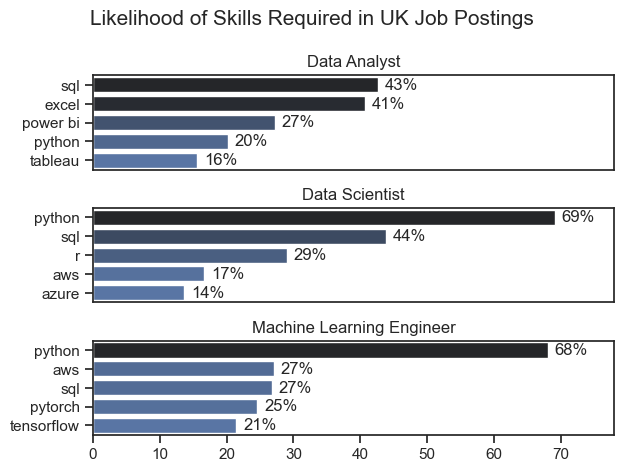

In [44]:
job_list = ['Data Analyst', 'Data Scientist', 'Machine Learning Engineer']

df_filtered = df[(df['job_title_short'].isin(job_list))&
            (df['job_country'] == 'United Kingdom')]

df_exploded = df_filtered.explode('job_skills').dropna(subset = 'job_skills')

df_grouped = (
    df_exploded.groupby(['job_title_short', 'job_skills'])
    .size()
    .reset_index(name = 'skill_count')
    .sort_values(by = 'skill_count', ascending = False)
)
df_total_jobs = (
    df_filtered['job_title_short'].value_counts()
    .reset_index(name = 'total_jobs')
)

df_skills_perc = pd.merge(df_grouped, df_total_jobs, on = 'job_title_short', how = 'left' )

df_skills_perc['percentage'] = (df_skills_perc['skill_count']/df_skills_perc['total_jobs'])*100

fig, ax = plt.subplots(len(job_list), 1)

sns.set_theme(style = 'ticks')
for i, job_name in enumerate(job_list):
    df_plot = df_skills_perc[df_skills_perc['job_title_short'] == job_name].head()
    sns.barplot(data = df_plot, x = 'percentage',
                 y  = 'job_skills',
                   ax = ax[i],
                     hue = 'percentage',
                        palette = 'dark:b_r')
    ax[i].set_title(job_name)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].get_legend().remove()
    ax[i].set_xlim(0, 78)

    if job_name != 'Machine Learning Engineer':
        ax[i].set_xticks([])

    for n, v in enumerate(df_plot['percentage']):
        ax[i].text(v + 1, n, f'{v:.0f}%', va='center')

fig.suptitle('Likelihood of Skills Required in UK Job Postings', fontsize = 15)
plt.tight_layout()
plt.show()